In [5]:
import sys
import os

# Go up 2 levels: from notebooks/ → restaurant_guest_forecasting/ → project root
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [6]:
import torch
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt

from restaurant_guest_forecasting.data.train_test_split import train_val_test_data
from restaurant_guest_forecasting.data.tensor_data import *
from restaurant_guest_forecasting.data.normalization import preprocess_df

from restaurant_guest_forecasting.models.mlp.mlp import MultiTaskMLP


Dates in train: 1365
Common dates in train and val: 0


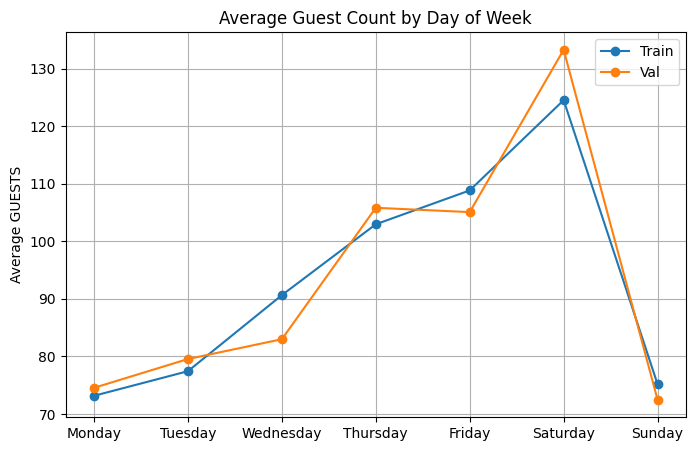

In [7]:
train_data, val_data, test_data = train_val_test_data()

dates_in_train = train_data["Date"]
print(f"Dates in train: {len(dates_in_train)}")
dates_in_val = val_data["Date"]


common_dates = set(dates_in_train) & set(dates_in_val)
print(f"Common dates in train and val: {len(common_dates)}")
if common_dates:
    print(sorted(common_dates))

# df = split_date(train_data, drop_date=True) 
# article_cols = [col for col in df.columns if col.startswith("art_")]
# df = df.drop(columns=article_cols)

# Plot average guest counts for each day of the week in train and val sets
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
train_means = [
    train_data.loc[train_data[f"is_{day}"] == 1, "GUESTS"].mean() for day in days
]
val_means = [
    val_data.loc[val_data[f"is_{day}"] == 1, "GUESTS"].mean() for day in days
]

plt.figure(figsize=(8, 5))
plt.plot(days, train_means, marker='o', label='Train')
plt.plot(days, val_means, marker='o', label='Val')
plt.ylabel("Average GUESTS")
plt.title("Average Guest Count by Day of Week")
plt.legend()
plt.grid(True)
plt.show()
# print(df.columns)
# # print(len(df.columns))

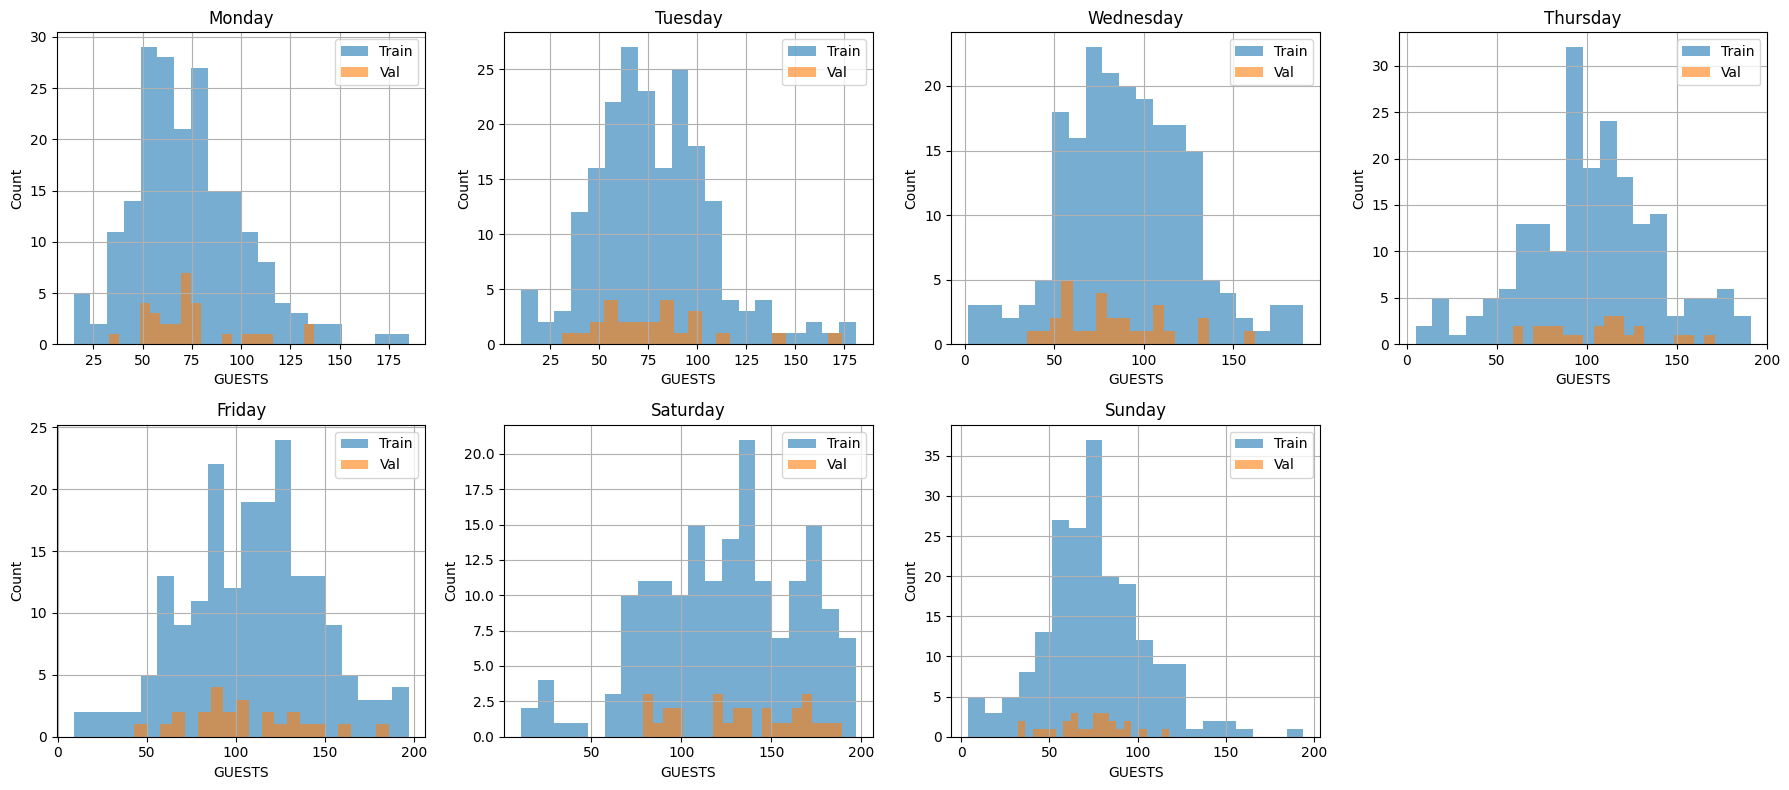

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, day in enumerate(days):
    ax = axes[i]
    train_data[train_data[f'is_{day}'] == 1]["GUESTS"].hist(
        ax=ax, alpha=0.6, label='Train', bins=20, color='tab:blue'
    )
    val_data[val_data[f'is_{day}'] == 1]["GUESTS"].hist(
        ax=ax, alpha=0.6, label='Val', bins=20, color='tab:orange'
    )
    ax.set_title(f"{day}")
    ax.set_xlabel("GUESTS")
    ax.set_ylabel("Count")
    ax.legend()

# Hide the last subplot if not used
if len(days) < len(axes):
    for j in range(len(days), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of GUESTS')

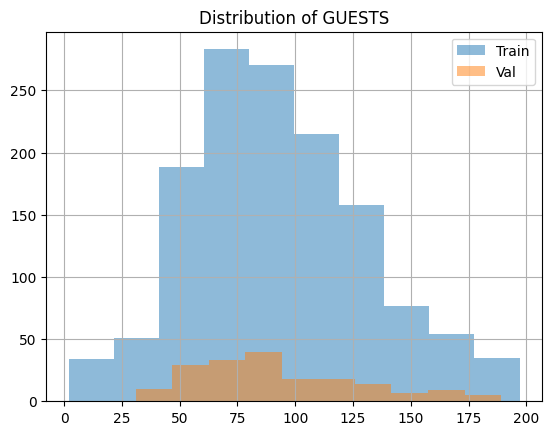

In [9]:
train_data["GUESTS"].hist(alpha=0.5, label='Train')
val_data["GUESTS"].hist(alpha=0.5, label='Val')
plt.legend(); plt.title("Distribution of GUESTS")

In [10]:
print(f"train_data['GUESTS'].mean(): {train_data['GUESTS'].mean()}")
print(f"val_data['GUESTS'].mean(): {val_data['GUESTS'].mean()}")
print(f"train_data['GUESTS'].std(): {train_data['GUESTS'].std()}")
print(f"val_data['GUESTS'].std(): {val_data['GUESTS'].std()}")

train_data['GUESTS'].mean(): 92.58534798534798
val_data['GUESTS'].mean(): 93.33879781420765
train_data['GUESTS'].std(): 38.30186961815467
val_data['GUESTS'].std(): 35.808172875764754


In [11]:
X, y = preprocess_df(train_data)

print(X.columns)

Index(['is_Friday', 'is_Monday', 'is_Saturday', 'is_Sunday', 'is_Thursday',
       'is_Tuesday', 'is_Wednesday', 'tempmax', 'tempmin', 'temp',
       'feelslikemax', 'feelslikemin', 'feelslike', 'humidity', 'precip',
       'precipprob', 'windgust', 'windspeed', 'cloudcover', 'solarradiation',
       'uvindex', 'rain', 'snow', 'IsHoliday', 'Ascension Day', 'Christmas',
       'Day of German Unity', 'Easter Monday', 'Good Friday', 'King's Day',
       'May Day', 'New Year's Day', 'Second Christmas Day', 'Whit Monday',
       'year', 'month', 'day_of_year'],
      dtype='object')
